# Task 3: Variant analysis with genome-wide off-target coverage

## Study questions

1. Are any eligible guides absent or unusable in any of the seven genomes?
2. Does predicted off-target risk differ among the seven genomes across the full eligible guide pool, at candidate sites anywhere in the genome?

This notebook extends `03_variant_analysis_all_eligible-KM` and uses the same 14 eligible guides, the same seven genomes and the same haplotype reconstruction. The one difference is coverage: it loads every prepared per-chromosome VCF, so CRISPOR off-target candidates are evaluated on every chromosome with data, not only on chr4 and chr18.

- **Question 1** is unchanged in scope, because every on-target site is on chr4 (CXCL11) or chr18 (SERPINB2).
- **Question 2** now covers off-target candidates on all chromosomes with a VCF. Sites on a chromosome without one are listed under *Genome-wide coverage* and are not counted as unchanged.

**Data preparation:** `python utils/prepare_regional_vcfs.py --chromosomes autosomes` builds VCFs for chr1–22.

**Not evaluated: chrX and chrY.** The 1000 Genomes 20190312 chrX file covers only the pseudoautosomal regions (PAR1 and PAR2), and no chrX candidate lies in either. The release has no chrY file at all. Candidates on both chromosomes are listed under *Genome-wide coverage* and are not counted as unchanged.

All outputs use the `task3_genome_wide_` prefix.

In [1]:
import os
import sys
from pathlib import Path

# Locate this Task3 folder from wherever the notebook is run, so the paths below
# do not depend on the working directory.
TASK3 = Path.cwd()
while not (TASK3 / 'utils' / 'variant_utils.py').exists() and TASK3 != TASK3.parent:
    TASK3 = TASK3.parent
sys.path.insert(0, str(TASK3))

# GRCh38 and the VCFs are too large for the repository. Set IFN646_DATA to
# wherever you downloaded them; see the README.
REF_DIR = Path(os.environ.get('IFN646_DATA', TASK3.parent / 'data'))

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xlrd

from matplotlib.colors import ListedColormap
from IPython.display import display, Markdown

# Import the refactored heavy-lifting variant logic and plotting functions
from utils.variant_utils import (
    VariantAnalyzer, orient_sequence, canonical_chromosome,
    plot_gene_grna_architecture, plot_all_chromosome_targets,
    plot_offtarget_events_by_chromosome, plot_offtarget_events_by_guide,
    risk_increasing_site_report, risk_increasing_guide_by_chromosome
)

DATA_DIR = REF_DIR
RESULTS_DIR = TASK3 / 'results'
TABLE_DIR = RESULTS_DIR / 'tables'
FIGURE_DIR = RESULTS_DIR / 'figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_FASTA = DATA_DIR / 'GRCh38.fa'
OFFTARGET_XLS = {
    'SERPINB2': TASK3 / 'inputs' / 'offtargets_hg38-chr18-63887679-63887795.xls',
    'CXCL11': TASK3 / 'inputs' / 'offtargets_hg38-chr4-76035901-76036222.xls',
}
VCF_DIR = DATA_DIR / 'vcfs'
GENE_REGIONS = {
    'SERPINB2': {'chrom':'18', 'start':63871692, 'end':63903888, 'mode':'CRISPRa'},
    'CXCL11': {'chrom':'4', 'start':76033682, 'end':76041415, 'mode':'CRISPRi'},
}

# Initialize VariantAnalyzer with every prepared per-chromosome VCF, so
# off-target sites anywhere in the genome can be evaluated.
#
# A VCF is loaded only if it actually covers the off-target sites. A VCF with no
# records at a site is read as reference, so loading one that does not cover a
# region would silently report every site there as unchanged.
UNCOVERED_CHROMS = {
    # The 1000 Genomes 20190312 chrX file contains only the pseudoautosomal
    # regions (PAR1 <= 2,781,479 and PAR2 >= 155,701,383). No chrX off-target
    # candidate lies in either, so chrX sites are reported as not evaluated.
    'X': 'source VCF covers only PAR1/PAR2; no chrX candidate lies in a PAR',
}
analyzer = VariantAnalyzer(REFERENCE_FASTA)
for vcf_path in sorted(VCF_DIR.glob('sampled_chr*.norm.vcf.gz')):
    chrom = re.fullmatch(r'sampled_chr(\w+)\.norm\.vcf\.gz', vcf_path.name).group(1)
    if chrom in UNCOVERED_CHROMS:
        print(f'Skipping chr{chrom}: {UNCOVERED_CHROMS[chrom]}')
        continue
    analyzer.add_vcf(chrom, vcf_path)

missing_on_target = [gene for gene, region in GENE_REGIONS.items() if region['chrom'] not in analyzer.vcfs]
assert not missing_on_target, f'On-target VCF missing for: {missing_on_target}'

SAMPLES = list(analyzer.vcfs['4'].header.samples)
sample_mismatch = [c for c, vcf in analyzer.vcfs.items() if list(vcf.header.samples) != SAMPLES]
assert not sample_mismatch, f'VCFs with a different sample set or order: {sample_mismatch}'

def chrom_order(c):
    return (0, int(c)) if str(c).isdigit() else (1, str(c))

print(f"Loaded {len(analyzer.vcfs)} chromosome VCFs: {', '.join(sorted(analyzer.vcfs, key=chrom_order))}")

Skipping chrX: source VCF covers only PAR1/PAR2; no chrX candidate lies in a PAR
Loaded 22 chromosome VCFs: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22


## Data integrity checks

Haplotype-level results are only meaningful on phased genotypes, and every
disruption rate below depends on that. This cell fails the notebook rather
than producing results that cannot be interpreted.


In [2]:

phasing = pd.DataFrame([analyzer.check_phasing(c) for c in analyzer.vcfs])
display(Markdown('**Phasing check — fraction of heterozygous genotypes carrying phase information**'))
display(phasing)
# A chromosome with no heterozygous genotypes in these regions has nothing to
# phase (phased_fraction is 0/0 = NaN), so it cannot fail the check.
has_het = phasing['heterozygous_genotypes'] > 0
if (~has_het).any():
    display(Markdown('No heterozygous genotypes, so phase is irrelevant: '
                     + ', '.join(f'chr{c}' for c in phasing.loc[~has_het, 'chrom'])))
assert (phasing.loc[has_het, 'phased_fraction'] > 0.99).all(), (
    'Haplotype-level analysis requires phased genotypes. See the table above: '
    'one or more VCFs are not phased, so hap1/hap2 assignment is arbitrary.'
)

display(Markdown(
    f'Reconstruction window: `{analyzer.pad}` bp either side of each target, '
    f'bounding the longest deletion that can be detected reaching in from outside.'
))


# Each prepared VCF holds only the regions it was built from, recorded in the
# sibling marker file. Checking the marker against the region list the notebook
# reads later catches the case where one was regenerated and the other was not -
# a mismatch there is silent in every downstream count, because a region that
# was never downloaded looks exactly like a region where nobody carries a
# variant.
REGION_BED = TASK3 / 'inputs' / 'task3_offtarget_regions.bed'
MARKER_SUFFIX = '.task3_regions_complete'
ON_TARGET_REGIONS = {'4': 1, '18': 1}   # added by the prep script, not in the BED

bed_counts = {}
for line in REGION_BED.read_text().splitlines():
    if line and not line.startswith('#'):
        key = canonical_chromosome(line.split('\t')[0])
        bed_counts[key] = bed_counts.get(key, 0) + 1

region_audit = []
for chrom, vcf in analyzer.vcfs.items():
    marker = Path(vcf.filename.decode() + MARKER_SUFFIX)
    built = next((int(x.split('=')[1]) for x in marker.read_text().splitlines()
                  if x.startswith('regions=')), None) if marker.exists() else None
    expected = bed_counts.get(str(chrom), 0) + ON_TARGET_REGIONS.get(str(chrom), 0)
    region_audit.append({'chrom': chrom, 'regions_in_vcf': built,
                         'regions_in_bed': expected, 'match': built == expected})

region_audit = pd.DataFrame(region_audit).sort_values('chrom', key=lambda s: s.map(chrom_order))
if not region_audit['match'].all():
    display(Markdown('**VCF / region-list mismatch**'))
    display(region_audit[~region_audit['match']])
    raise RuntimeError(
        'The prepared VCFs were not built from the region list this notebook reads. '
        'Rebuild them before trusting any off-target result: sites outside the regions '
        'a VCF was built from carry no records, and would be counted as carrying no variant.'
    )
display(Markdown(
    f'Region-list check: all `{len(region_audit)}` VCFs were built from the current '
    f'`{REGION_BED.name}` (`{int(region_audit["regions_in_bed"].sum()):,}` regions).'
))

**Phasing check — fraction of heterozygous genotypes carrying phase information**

,chrom,records_examined,heterozygous_genotypes,phased_heterozygous,phased_fraction
0,1,760,176,176,1.0
1,10,472,117,117,1.0
2,11,550,110,110,1.0
3,12,543,103,103,1.0
4,13,315,76,76,1.0
5,14,261,51,51,1.0
6,15,336,96,96,1.0
7,16,319,65,65,1.0
8,17,306,77,77,1.0
9,18,310,71,71,1.0


Reconstruction window: `50` bp either side of each target, bounding the longest deletion that can be detected reaching in from outside.

Region-list check: all `22` VCFs were built from the current `task3_offtarget_regions.bed` (`2,769` regions).

## Reference validation of ALL eligible guides

In [3]:
# Load the full pool of eligible guides extracted separately for each chromosome
cxcl11_df = pd.read_csv(TASK3 / 'inputs' / 'task2_cxcl11_crispri_full_pool.csv')
cxcl11_df['gene'] = 'CXCL11'
cxcl11_df['mode'] = 'CRISPRi'

serpinb2_df = pd.read_csv(TASK3 / 'inputs' / 'task2_serpinb2_crispra_full_pool.csv')
serpinb2_df['gene'] = 'SERPINB2'
serpinb2_df['mode'] = 'CRISPRa'

guides = pd.concat([cxcl11_df, serpinb2_df], ignore_index=True)
guides = guides.rename(columns={
    '#guideId': 'guide_id',
    'mapped_orientation': 'crispor_strand',
    'Composite_Score': 'task2_composite'
})

# Retain only the columns expected by the downstream code
guides = guides[['gene', 'mode', 'guide_id', 'targetSeq', 'crispor_strand', 'task2_composite']]
guides['targetSeq'] = guides['targetSeq'].astype(str).str.upper().str.replace(r'[^ACGTN]', '', regex=True)

if not guides['targetSeq'].str.len().eq(23).all():
    raise ValueError('Every selected targetSeq must contain 23 bases.')
if guides[['gene', 'guide_id']].duplicated().any():
    raise ValueError('Duplicate gene-guide identifiers were found.')

def map_guide(row):
    region = GENE_REGIONS[row['gene']]
    chrom = region['chrom']
    fasta_chrom = analyzer.fasta_contigs.get(canonical_chromosome(chrom), chrom)
    region_sequence = analyzer.reference.fetch(fasta_chrom, region['start'] - 1, region['end']).upper()
    matches = []
    for strand, query in {'+':row['targetSeq'], '-':orient_sequence(row['targetSeq'], '-')}.items():
        for match in re.finditer(f'(?={re.escape(query)})', region_sequence):
            start = region['start'] + match.start()
            matches.append((start, start + 22, strand))
    if len(matches) != 1:
        return pd.Series({'fasta_chrom':chrom,'guide_start':pd.NA,'guide_end':pd.NA,'genomic_strand':pd.NA,'mapping_status':'NOT_FOUND' if not matches else 'AMBIGUOUS'})
    start, end, strand = matches[0]
    genomic = analyzer.reference.fetch(fasta_chrom, start - 1, end).upper()
    oriented = orient_sequence(genomic, strand)
    status = 'VALIDATED' if oriented == row['targetSeq'] and oriented[-3:].endswith('GG') else 'REFERENCE_OR_PAM_MISMATCH'
    return pd.Series({'fasta_chrom':chrom,'guide_start':start,'guide_end':end,'genomic_strand':strand,'mapping_status':status})

mapping = guides.apply(map_guide, axis=1)
for column in mapping.columns:
    guides[column] = mapping[column].values
if not guides['mapping_status'].eq('VALIDATED').all():
    display(guides.loc[guides['mapping_status'] != 'VALIDATED'])
    raise RuntimeError('At least one selected guide failed reference validation.')

guides.to_csv(TABLE_DIR / 'task3_genome_wide_guide_manifest.tsv', sep='	', index=False)
display(guides[['gene','guide_id','targetSeq','crispor_strand','genomic_strand','guide_start','guide_end','mapping_status']])

,gene,guide_id,targetSeq,crispor_strand,genomic_strand,guide_start,guide_end,mapping_status
0,CXCL11,76forw,GAAAGGTGCATGACTCAAAGAGG,reverse,-,76036145,76036167,VALIDATED
1,CXCL11,264forw,GAAGGGCATGGCTATAGCCTTGG,reverse,-,76035957,76035979,VALIDATED
2,CXCL11,261rev,AGCACACAATATCACAGCCAAGG,forward,+,76035940,76035962,VALIDATED
3,CXCL11,295forw,TTGTGTGCTACAGTTGTTCAAGG,reverse,-,76035926,76035948,VALIDATED
4,CXCL11,77forw,AAAGGTGCATGACTCAAAGAGGG,reverse,-,76036144,76036166,VALIDATED
5,CXCL11,106forw,CTGTGCCATAAAAGGATTGCTGG,reverse,-,76036115,76036137,VALIDATED
6,CXCL11,145rev,GTAGAAATGCTGAACATGAAAGG,forward,+,76036056,76036078,VALIDATED
7,CXCL11,169rev,GCTTTGCTGCTCTTCTTGGAAGG,forward,+,76036032,76036054,VALIDATED
8,CXCL11,98forw,GGAAATTCCTGTGCCATAAAAGG,reverse,-,76036123,76036145,VALIDATED
9,SERPINB2,40forw,TGAACTGTAACAACTCTCAGAGG,forward,+,63887699,63887721,VALIDATED


**Observations:**

- All 14 eligible guides (9 for CXCL11 on Chr 4, 5 for SERPINB2 on Chr 18) mapped uniquely and reproduced their expected 23-base GRCh38 target with a compatible NGG PAM.
- The inferred genomic orientation differed from the CRISPOR display label for 14 guide(s) (CRISPOR label reflects transcription orientation relative to gene direction):
    - CXCL11 (Chr 4): 76forw, 264forw, 261rev, 295forw, 77forw, 106forw, 145rev, 169rev, 98forw
    - SERPINB2 (Chr 18): 40forw, 90forw, 50rev, 77rev, 51rev
- The inferred genomic strand was used for all allele reconstruction, preventing strand-related PAM errors.

### Visualisation of Gene Architecture, First Exon, and ALL Eligible gRNA / PAM Binding Sites

The following figures illustrate the full gene sequence architecture for each chromosome alongside high-resolution target views:
- **Full Gene Architecture (Panel A):** Complete gene locus on its respective chromosome (CXCL11 on Chr 4, SERPINB2 on Chr 18), all exons, introns with transcription orientation arrows, and prominently highlights the first exon targeted for CRISPR modulation.
- **Target Locus Architecture & gRNA / PAM Binding (Panel B):** Zooms into the first exon window, displaying the exact first exon boundaries, and visualising each eligible 20nt protospacer, its corresponding 3nt PAM region, strand orientation, and predicted SpCas9 cleavage site (cut marker) with dedicated horizontal lanes ensuring zero overlap.

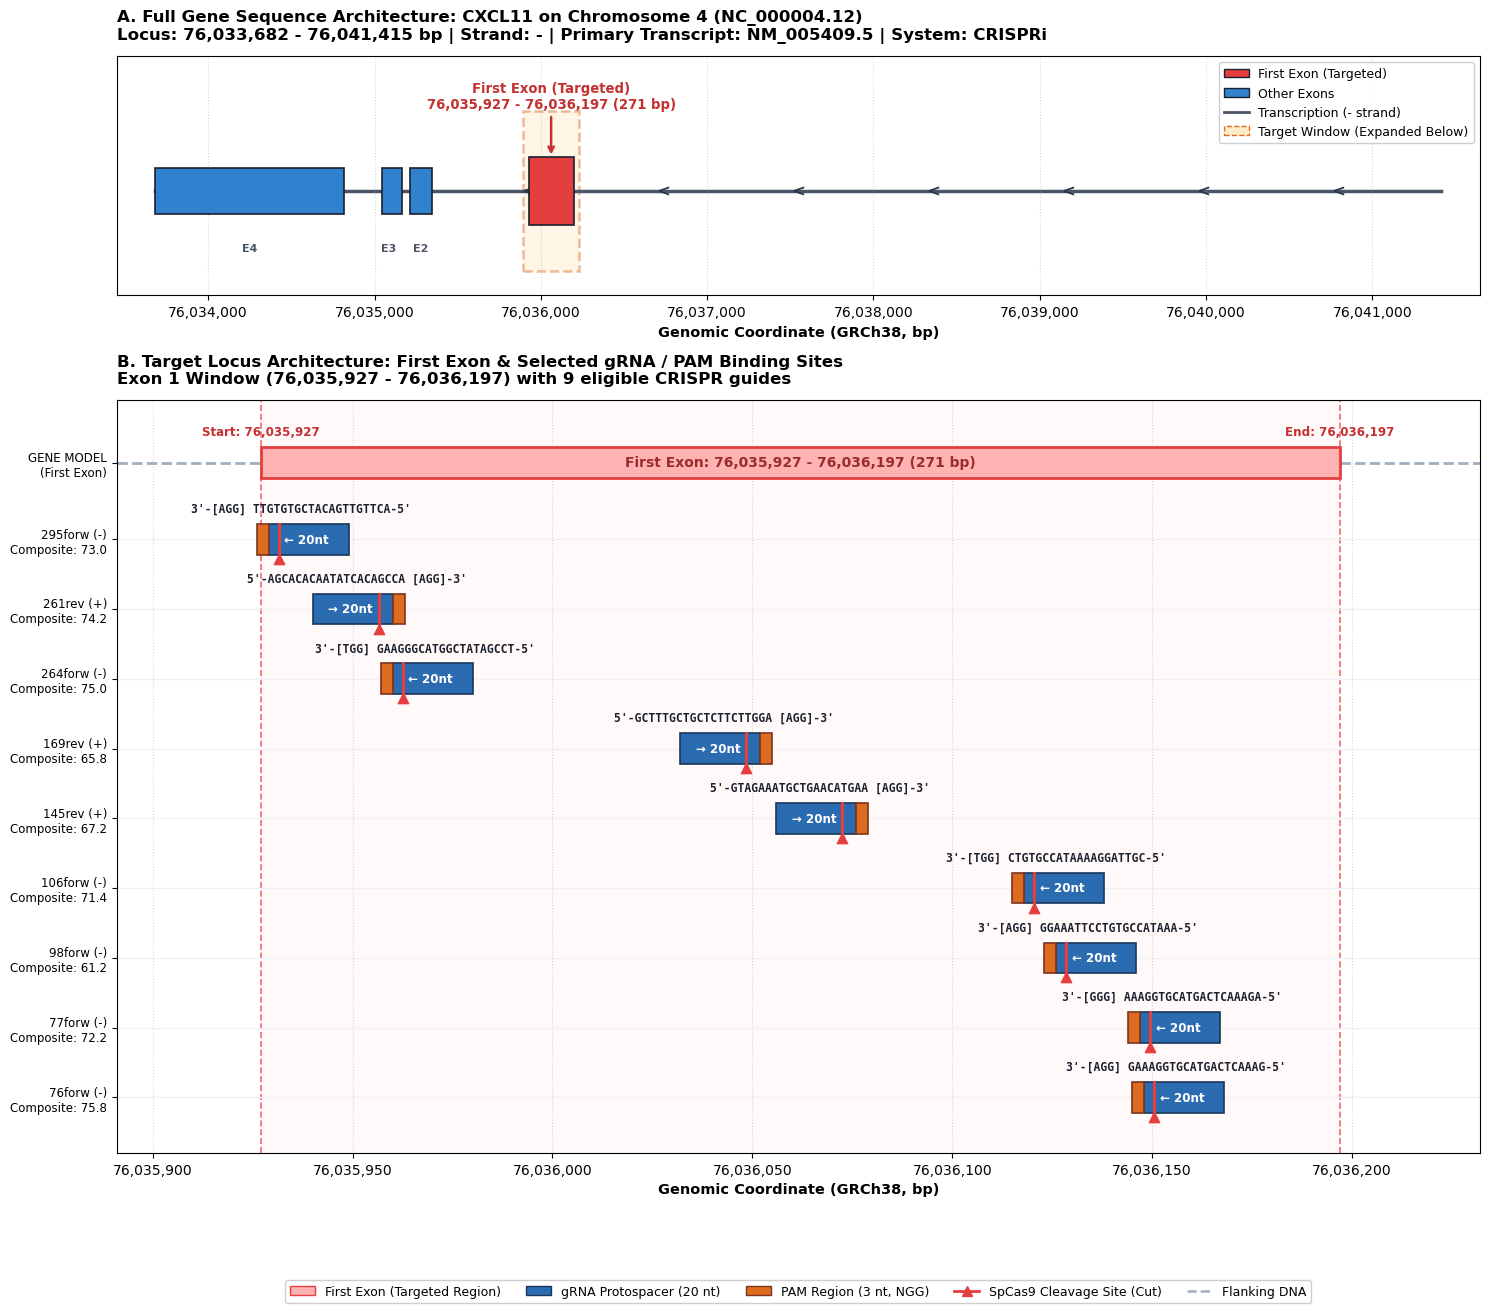

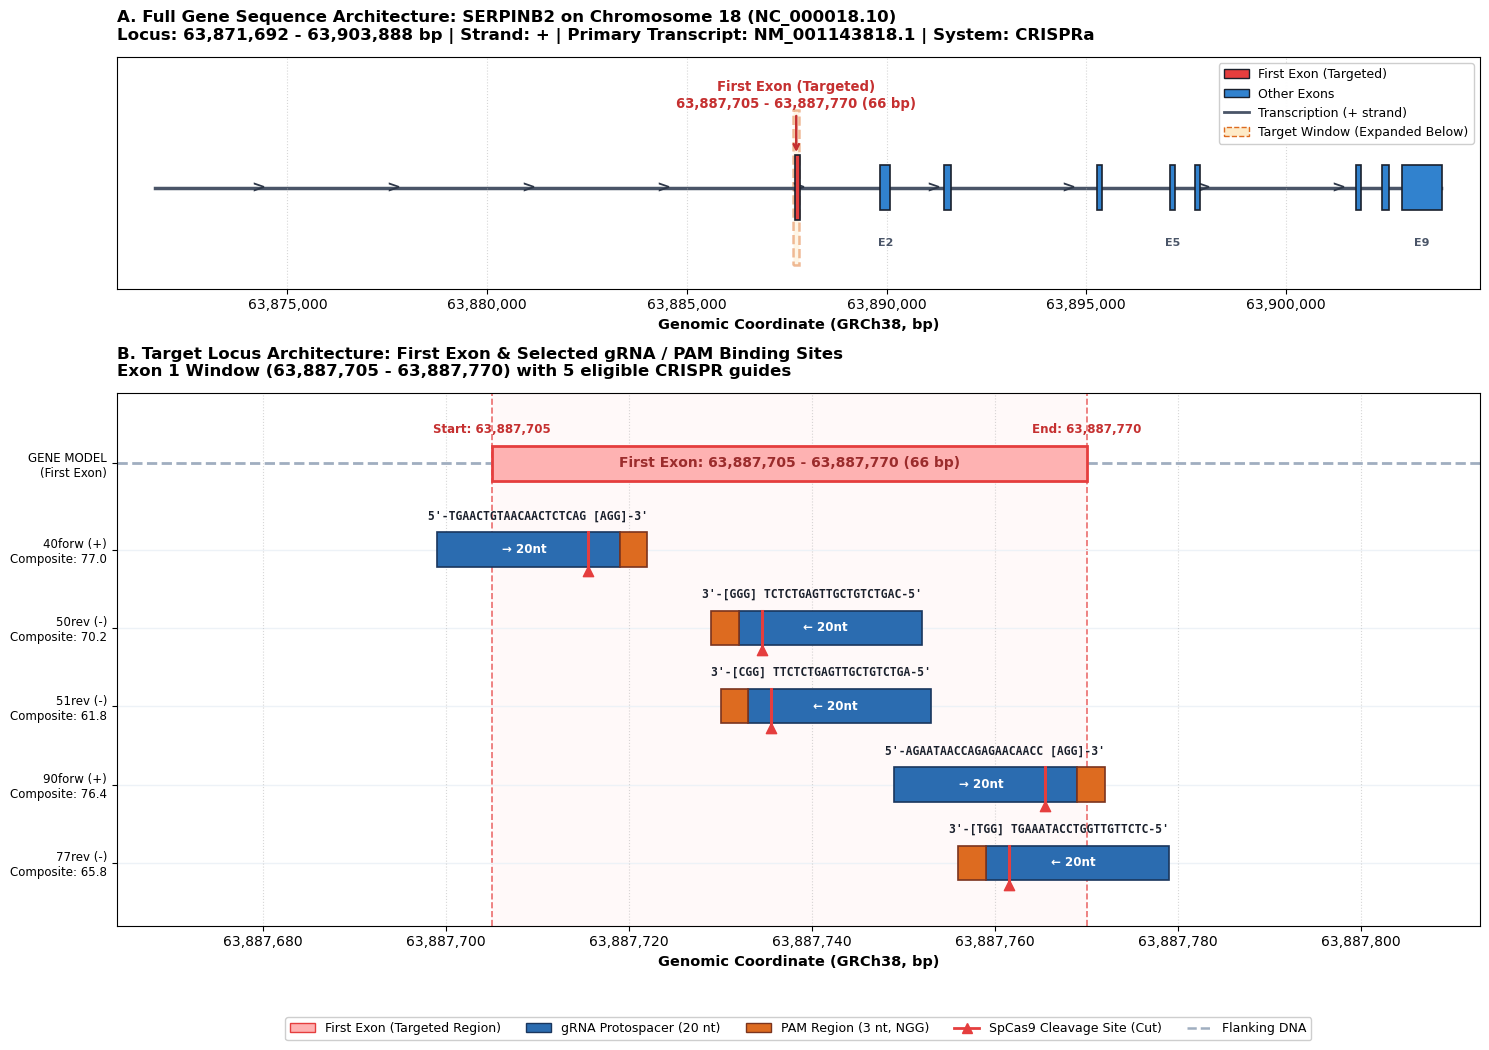

In [4]:
# Visualise gene sequence, first exon, and all eligible gRNA/PAM binding sites for each chromosome
for chrom, gene in [('4', 'CXCL11'), ('18', 'SERPINB2')]:
    plot_gene_grna_architecture(
        gene_or_chrom=gene,
        guides_df=guides,
        output_path=FIGURE_DIR / f'task3_{gene.lower()}_genome_wide_grna_architecture.png',
        show=True
    )

## On-target availability across seven genomes (ALL eligible guides)

In [5]:
rows = []
for _, guide in guides.iterrows():
    start, end = int(guide['guide_start']), int(guide['guide_end'])
    for sample_id in SAMPLES:
        allele_1, allele_2, reconstruction = analyzer.reconstruct_alleles(guide['fasta_chrom'], start, end, sample_id)
        for haplotype, allele in enumerate([allele_1, allele_2], 1):
            personalised = orient_sequence(allele, guide['genomic_strand'])
            rows.append({
                'sample_id':sample_id,'gene':guide['gene'],'mode':guide['mode'],'guide_id':guide['guide_id'],
                'haplotype':haplotype,'reconstruction_status':reconstruction,'personalised_23mer':personalised,
                'target_status':analyzer.classify_on_target(guide['targetSeq'], personalised)
            })
personalised_targets = pd.DataFrame(rows)
personalised_targets.to_csv(TABLE_DIR / 'task3_genome_wide_personalised_targets.tsv', sep='\t', index=False)

guide_sample_summary = (
    personalised_targets.groupby(['sample_id', 'gene', 'mode', 'guide_id'], as_index=False)
    .agg(
        targetable_alleles=('target_status', lambda s: (s == 'UNCHANGED').sum()),
        target_statuses=('target_status', lambda s: ','.join(s)),
        reconstruction_statuses=('reconstruction_status', lambda s: ','.join(s)),
    )
)
guide_sample_summary['guide_status'] = np.select(
    [
        guide_sample_summary['targetable_alleles'] == 2,
        guide_sample_summary['targetable_alleles'] == 1,
    ],
    ['PASS', 'CAUTION'],
    default='FAIL',
)
guide_sample_summary.to_csv(TABLE_DIR / 'task3_genome_wide_guide_sample_summary.tsv', sep='\t', index=False)

question1_summary = (
    guide_sample_summary.groupby(['gene', 'mode', 'guide_id'], as_index=False)
    .agg(
        evaluable_individuals=('sample_id', 'nunique'),
        passing_individuals=('guide_status', lambda s: (s == 'PASS').sum()),
        minimum_targetable_alleles=('targetable_alleles', 'min'),
    )
)
question1_summary['answer'] = np.where(
    question1_summary['passing_individuals'] == question1_summary['evaluable_individuals'],
    'RETAINED_IN_ALL_SEVEN',
    np.where(question1_summary['passing_individuals'] > 0, 'PARTIALLY_RETAINED', 'LOST_IN_ALL_SEVEN')
)
question1_summary.to_csv(TABLE_DIR / 'task3_genome_wide_question1_summary.tsv', sep='\t', index=False)
display(question1_summary)

,gene,mode,guide_id,evaluable_individuals,passing_individuals,minimum_targetable_alleles,answer
0,CXCL11,CRISPRi,106forw,7,7,2,RETAINED_IN_ALL_SEVEN
1,CXCL11,CRISPRi,145rev,7,7,2,RETAINED_IN_ALL_SEVEN
2,CXCL11,CRISPRi,169rev,7,7,2,RETAINED_IN_ALL_SEVEN
3,CXCL11,CRISPRi,261rev,7,7,2,RETAINED_IN_ALL_SEVEN
4,CXCL11,CRISPRi,264forw,7,7,2,RETAINED_IN_ALL_SEVEN
5,CXCL11,CRISPRi,295forw,7,7,2,RETAINED_IN_ALL_SEVEN
6,CXCL11,CRISPRi,76forw,7,7,2,RETAINED_IN_ALL_SEVEN
7,CXCL11,CRISPRi,77forw,7,7,2,RETAINED_IN_ALL_SEVEN
8,CXCL11,CRISPRi,98forw,7,7,2,RETAINED_IN_ALL_SEVEN
9,SERPINB2,CRISPRa,40forw,7,7,2,RETAINED_IN_ALL_SEVEN


**Observations:**

- None of the fourteen eligible guides was lost or rendered unusable in the seven genomes. Every guide passed in all seven individuals and retained two targetable alleles (196/196 reconstructed alleles were UNCHANGED).
- Retained eligible guides:
    - CXCL11 (Chr 4): 76forw, 264forw, 261rev, 295forw, 77forw, 106forw, 145rev, 169rev, 98forw
    - SERPINB2 (Chr 18): 40forw, 90forw, 50rev, 77rev, 51rev
- Consequently, both full eligible pools maintained 100% on-target availability across all analysed individuals.

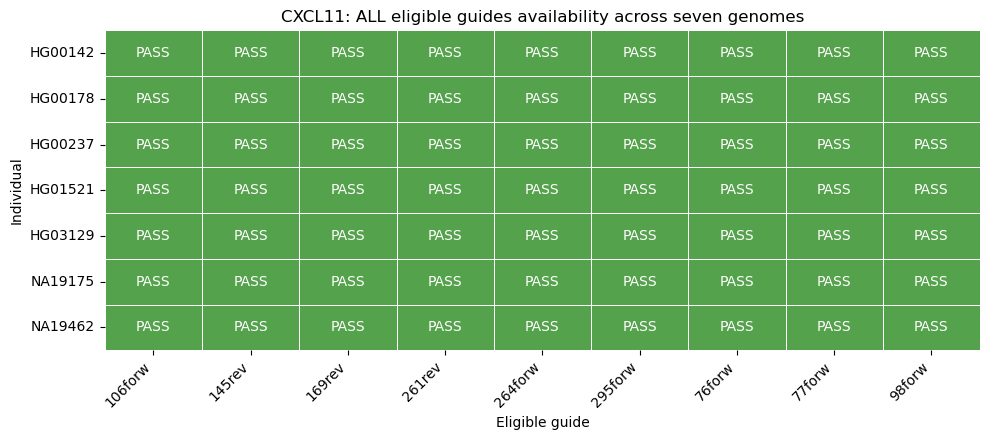

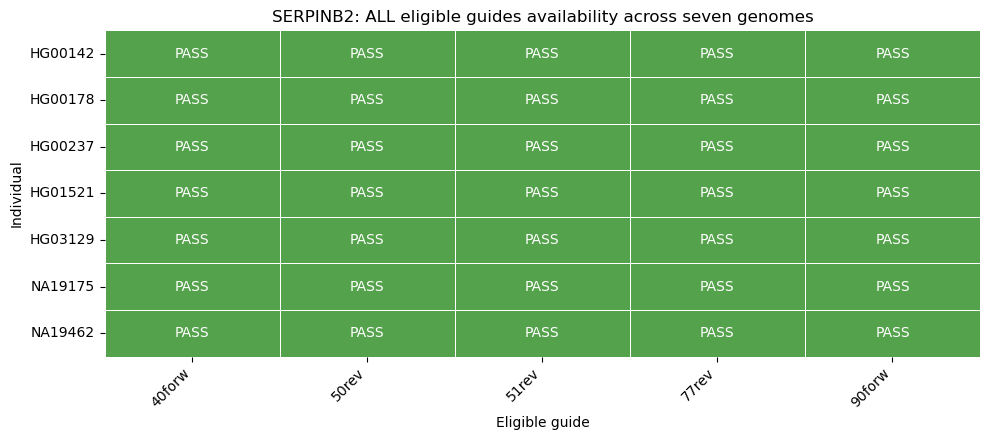

In [6]:
status_scores={'FAIL':0,'CAUTION':1,'PASS':2}
for gene in guides['gene'].unique():
    labels=guide_sample_summary.query('gene == @gene').pivot(index='sample_id',columns='guide_id',values='guide_status')
    scores=labels.apply(lambda column:column.map(status_scores)).astype(float)
    plt.figure(figsize=(10, 4.5))
    sns.heatmap(scores,cmap=ListedColormap(['#E45756','#F2CF5B','#54A24B']),vmin=-0.5,vmax=2.5,
                annot=labels.to_numpy(),fmt='',linewidths=.5,linecolor='white',cbar=False)
    plt.title(f'{gene}: ALL eligible guides availability across seven genomes')
    plt.xlabel('Eligible guide');plt.ylabel('Individual');plt.xticks(rotation=45,ha='right');plt.tight_layout()
    plt.savefig(FIGURE_DIR / f'task3_{gene.lower()}_genome_wide_on_target_heatmap.png',dpi=200,bbox_inches='tight')
    plt.show()

## CRISPOR candidate-site validation (ALL eligible guides)

In [7]:
def read_crispor_xls(path, gene):
    sheet = xlrd.open_workbook(str(path)).sheet_by_index(0)
    header = next((i for i in range(sheet.nrows) if str(sheet.cell_value(i,0)).strip() == 'guideId'), None)
    if header is None: raise ValueError(f'guideId header not found in {path.name}')
    names=[str(x).strip() for x in sheet.row_values(header)]
    records=[dict(zip(names,sheet.row_values(i))) for i in range(header+1,sheet.nrows) if str(sheet.cell_value(i,0)).strip()]
    return pd.DataFrame(records).rename(columns={
        'guideId':'guide_id','guideSeq':'guide_sequence','offtargetSeq':'offtarget_sequence',
        'mismatchCount':'reference_mismatch_count_crispor','mitOfftargetScore':'reference_mit_score',
        'cfdOfftargetScore':'reference_cfd_score','locusDesc':'locus_description'
    }).assign(gene=gene,source_file=path.name)

all_offtargets = pd.concat([read_crispor_xls(path,gene) for gene,path in OFFTARGET_XLS.items()],ignore_index=True)
for column in ['guide_id','guide_sequence','offtarget_sequence','chrom','locus_description']:
    all_offtargets[column]=all_offtargets[column].astype(str).str.strip()
all_offtargets['strand_raw']=all_offtargets['strand'].astype(str).str.strip()
all_offtargets['strand']=all_offtargets['strand_raw'].str.extract(r'^([+-])',expand=False)
all_offtargets['chrom'] = all_offtargets['chrom'].map(canonical_chromosome)
all_offtargets['start_raw']=pd.to_numeric(all_offtargets['start'],errors='raise').astype(int)
all_offtargets['end_raw']=pd.to_numeric(all_offtargets['end'],errors='raise').astype(int)

# Filter by all 14 eligible guides
pairs = set(map(tuple, guides[['gene','guide_id']].to_numpy()))
off_targets = all_offtargets.loc[all_offtargets.apply(lambda row:(row['gene'],row['guide_id']) in pairs,axis=1)].copy()

def resolve_site(row):
    chrom = row['chrom']
    fasta_chrom = analyzer.fasta_contigs.get(chrom)
    if not fasta_chrom:
        return pd.Series({'fasta_chrom':pd.NA,'start_1based':pd.NA,'end_1based':pd.NA,'reference_valid':False,'site_validation_status':'REFERENCE_CONTIG_UNAVAILABLE'})
    candidates=[(row['start_raw'],row['end_raw'],row['start_raw']-1,row['end_raw']),
                (row['start_raw']+1,row['end_raw']+1,row['start_raw'],row['end_raw']+1)]
    matches=[]
    for start,end,fetch_start,fetch_end in candidates:
        sequence=analyzer.reference.fetch(fasta_chrom,fetch_start,fetch_end).upper()
        if orient_sequence(sequence,row['strand']) == row['offtarget_sequence']:
            matches.append((start,end))
    if len(matches)!=1:
        return pd.Series({'fasta_chrom':chrom,'start_1based':pd.NA,'end_1based':pd.NA,'reference_valid':False,
                          'site_validation_status':'SEQUENCE_NOT_MATCHED' if not matches else 'COORDINATE_AMBIGUOUS'})
    return pd.Series({'fasta_chrom':chrom,'start_1based':matches[0][0],'end_1based':matches[0][1],
                      'reference_valid':True,'site_validation_status':'VALIDATED'})

site_mapping=off_targets.apply(resolve_site,axis=1)
off_targets=pd.concat([off_targets.reset_index(drop=True),site_mapping.reset_index(drop=True)],axis=1)
off_targets['offtarget_id']=[f'OT{i+1:05d}' for i in range(len(off_targets))]
validated_offtargets=off_targets.loc[off_targets['reference_valid']].copy()
excluded_reference_sites=off_targets.loc[~off_targets['reference_valid']].copy()
validated_offtargets['start_1based']=validated_offtargets['start_1based'].astype(int)
validated_offtargets['end_1based']=validated_offtargets['end_1based'].astype(int)

off_targets.to_csv(TABLE_DIR/'task3_genome_wide_selected_crispor_offtargets_all.tsv',sep='\t',index=False)
validated_offtargets.to_csv(TABLE_DIR/'task3_genome_wide_selected_crispor_offtargets_validated.tsv',sep='\t',index=False)
display(off_targets.groupby('site_validation_status',dropna=False).size().reset_index(name='candidate_sites'))

,site_validation_status,candidate_sites
0,REFERENCE_CONTIG_UNAVAILABLE,4
1,VALIDATED,2887


## Off-target candidate coverage and Personalised evaluation (ALL eligible guides)

In [8]:
# Process off-targets and apply VCF availability and region-coverage checks
# A site can only be evaluated if its chromosome has a VCF AND the site lies
# inside the regions that VCF was built from. A site outside those regions has
# no records for a reason that has nothing to do with the cohort, and must not
# be read as "no variant in anyone".
region_index = {}
for line in REGION_BED.read_text().splitlines():
    if line and not line.startswith('#'):
        f = line.split('\t')
        region_index.setdefault(canonical_chromosome(f[0]), []).append(
            (int(f[1]) + 1, int(f[2])))

def site_in_prepared_regions(chrom, start, end):
    return any(a <= end and start <= b for a, b in region_index.get(str(chrom), []))

def assert_regions_cover_guides(sites, has_vcf, in_regions):
    """Fail rather than under-report. The guide pool and the region list are
    built by separate steps, and the list going stale when the pool is widened
    is silent in every downstream number."""
    stale = (sites[has_vcf].assign(covered=in_regions[has_vcf])
             .groupby(['gene', 'guide_id'])['covered'].agg(sites='size', covered='sum'))
    stale['uncovered'] = stale['sites'] - stale['covered']
    stale = stale[stale['uncovered'] > 0]
    if len(stale):
        display(Markdown('**Guides with candidate sites outside the prepared VCF regions**'))
        display(stale)
        raise RuntimeError(
            f'{REGION_BED.name} does not cover every guide being analysed: '
            f'{int(stale["uncovered"].sum())} candidate sites across {len(stale)} guides '
            'were never downloaded, so those guides would be reported as clean because '
            'nothing was looked at. Regenerate the region list and rebuild the VCFs.'
        )

has_vcf = validated_offtargets['chrom'].astype(str).isin(analyzer.vcfs.keys())
in_regions = pd.Series(
    [site_in_prepared_regions(r.chrom, r.start_1based, r.end_1based)
     for r in validated_offtargets.itertuples()], index=validated_offtargets.index)
assert_regions_cover_guides(validated_offtargets, has_vcf, in_regions)

is_analysable = has_vcf & in_regions
validated_offtargets['evaluation_status'] = np.select(
    [is_analysable, ~has_vcf], ['ANALYSABLE', 'NO_VCF_FOR_CHROMOSOME'],
    default='OUTSIDE_PREPARED_REGIONS')
analysable_offtargets = validated_offtargets[is_analysable].copy()
missing_vcf = validated_offtargets[~is_analysable].copy()
print(f"Total candidates: {len(off_targets)}, Analysable: {len(analysable_offtargets)}, Not evaluated: {len(missing_vcf)}")

rows=[]
for _,site in analysable_offtargets.iterrows():
    guide=guides.loc[(guides['gene']==site['gene'])&(guides['guide_id']==site['guide_id'])].iloc[0]
    chrom = site['chrom']; start=int(site['start_1based']); end=int(site['end_1based'])
    ref_sequence = analyzer.reference.fetch(analyzer.fasta_contigs.get(chrom,chrom), start - 1, end).upper()
    ref_oriented = orient_sequence(ref_sequence, site['strand'])
    guide_20mer = guide['targetSeq'][:20]
    for sample_id in SAMPLES:
        allele_1, allele_2, reconstruction = analyzer.reconstruct_alleles(chrom, start, end, sample_id)
        for haplotype, allele in enumerate([allele_1, allele_2], 1):
            personalised_site = orient_sequence(allele, site['strand'])
            effect = analyzer.classify_off_target(guide_20mer, ref_oriented, personalised_site)
            rows.append({
                'sample_id':sample_id,'gene':site['gene'],'mode':guide['mode'],'guide_id':site['guide_id'],
                'offtarget_id':site['offtarget_id'],'chrom':chrom,'start_1based':start,'end_1based':end,
                'strand':site['strand'],'haplotype':haplotype,'reconstruction_status':reconstruction,
                'ref_site_23mer':ref_oriented,'personalised_site_23mer':personalised_site,'offtarget_effect':effect
            })

personalised_offtargets = pd.DataFrame(rows)
personalised_offtargets.to_csv(TABLE_DIR / 'task3_genome_wide_personalised_offtargets.tsv', sep='\t', index=False)

question2_summary = (
    personalised_offtargets.groupby(['sample_id', 'gene', 'mode', 'guide_id'], as_index=False)
    .agg(
        evaluated_haplotypes=('haplotype', 'count'),
        created_sites=('offtarget_effect', lambda s: (s == 'CREATED').sum()),
        increased_sites=('offtarget_effect', lambda s: (s == 'INCREASED').sum()),
        removed_sites=('offtarget_effect', lambda s: (s == 'REMOVED').sum()),
        decreased_sites=('offtarget_effect', lambda s: (s == 'DECREASED').sum()),
        unchanged_sites=('offtarget_effect', lambda s: (s == 'UNCHANGED').sum()),
        unresolved_sites=('offtarget_effect', lambda s: (s == 'UNRESOLVED').sum()),
    )
)
question2_summary['answer'] = 'NO_SEQUENCE_LEVEL_CHANGE_DETECTED'
has_risk_increase = (question2_summary['created_sites'] + question2_summary['increased_sites']).gt(0)
has_risk_decrease = (question2_summary['removed_sites'] + question2_summary['decreased_sites']).gt(0)
question2_summary.loc[has_risk_increase & ~has_risk_decrease, 'answer'] = 'RISK_INCREASE_DETECTED'
question2_summary.loc[~has_risk_increase & has_risk_decrease, 'answer'] = 'RISK_DECREASE_DETECTED'
question2_summary.loc[has_risk_increase & has_risk_decrease, 'answer'] = 'MIXED_CHANGE'
question2_summary.loc[question2_summary['unresolved_sites'].gt(0), 'answer'] = 'UNRESOLVED_OBSERVATIONS_PRESENT'

question2_summary.to_csv(TABLE_DIR / 'task3_genome_wide_question2_summary.tsv', sep='\t', index=False)
display(question2_summary.head(14))

Total candidates: 2891, Analysable: 2726, Not evaluated: 161


,sample_id,gene,mode,guide_id,evaluated_haplotypes,created_sites,increased_sites,removed_sites,decreased_sites,unchanged_sites,unresolved_sites,answer
0,HG00142,CXCL11,CRISPRi,106forw,190,0,0,0,1,189,0,RISK_DECREASE_DETECTED
1,HG00142,CXCL11,CRISPRi,145rev,532,0,1,0,3,528,0,MIXED_CHANGE
2,HG00142,CXCL11,CRISPRi,169rev,450,0,0,0,1,448,1,UNRESOLVED_OBSERVATIONS_PRESENT
3,HG00142,CXCL11,CRISPRi,261rev,556,0,0,2,1,552,1,UNRESOLVED_OBSERVATIONS_PRESENT
4,HG00142,CXCL11,CRISPRi,264forw,296,0,0,1,7,288,0,RISK_DECREASE_DETECTED
5,HG00142,CXCL11,CRISPRi,295forw,312,0,0,0,1,311,0,RISK_DECREASE_DETECTED
6,HG00142,CXCL11,CRISPRi,76forw,304,0,0,0,0,304,0,NO_SEQUENCE_LEVEL_CHANGE_DETECTED
7,HG00142,CXCL11,CRISPRi,77forw,408,0,0,1,3,401,3,UNRESOLVED_OBSERVATIONS_PRESENT
8,HG00142,CXCL11,CRISPRi,98forw,358,0,0,1,4,352,1,UNRESOLVED_OBSERVATIONS_PRESENT
9,HG00142,SERPINB2,CRISPRa,40forw,298,0,1,0,3,294,0,MIXED_CHANGE


### Genome-wide coverage

How many validated CRISPOR candidates could be evaluated, and where the rest are. A site on a chromosome without a VCF is reported here, never counted as unchanged.

**Validated off-target candidates evaluated, by gene**

,validated_sites,analysable_sites,no_vcf_sites,percent_analysable
gene,,,,
CXCL11,1810,1703,107,94.1
SERPINB2,1077,1023,54,95.0


**Validated candidates on chromosomes with no VCF (not evaluated)**

gene,CXCL11,SERPINB2
chrom,,
X,85,48
Y,22,6


**Off-target effects by chromosome (haplotype observations)**

offtarget_effect,DECREASED,INCREASED,REMOVED,UNCHANGED,UNRESOLVED
chrom,,,,,
1,19,2,0,3296,1
2,28,0,13,3377,12
3,31,1,0,2919,3
4,27,22,0,2302,1
5,43,1,0,2474,2
6,4,0,11,2056,1
7,22,0,6,2267,1
8,19,0,0,1619,0
9,44,0,1,1634,1


/Users/katrinamcmiddlin/repos/ifn646-task3/Task3/utils/variant_utils.py:458: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.95))


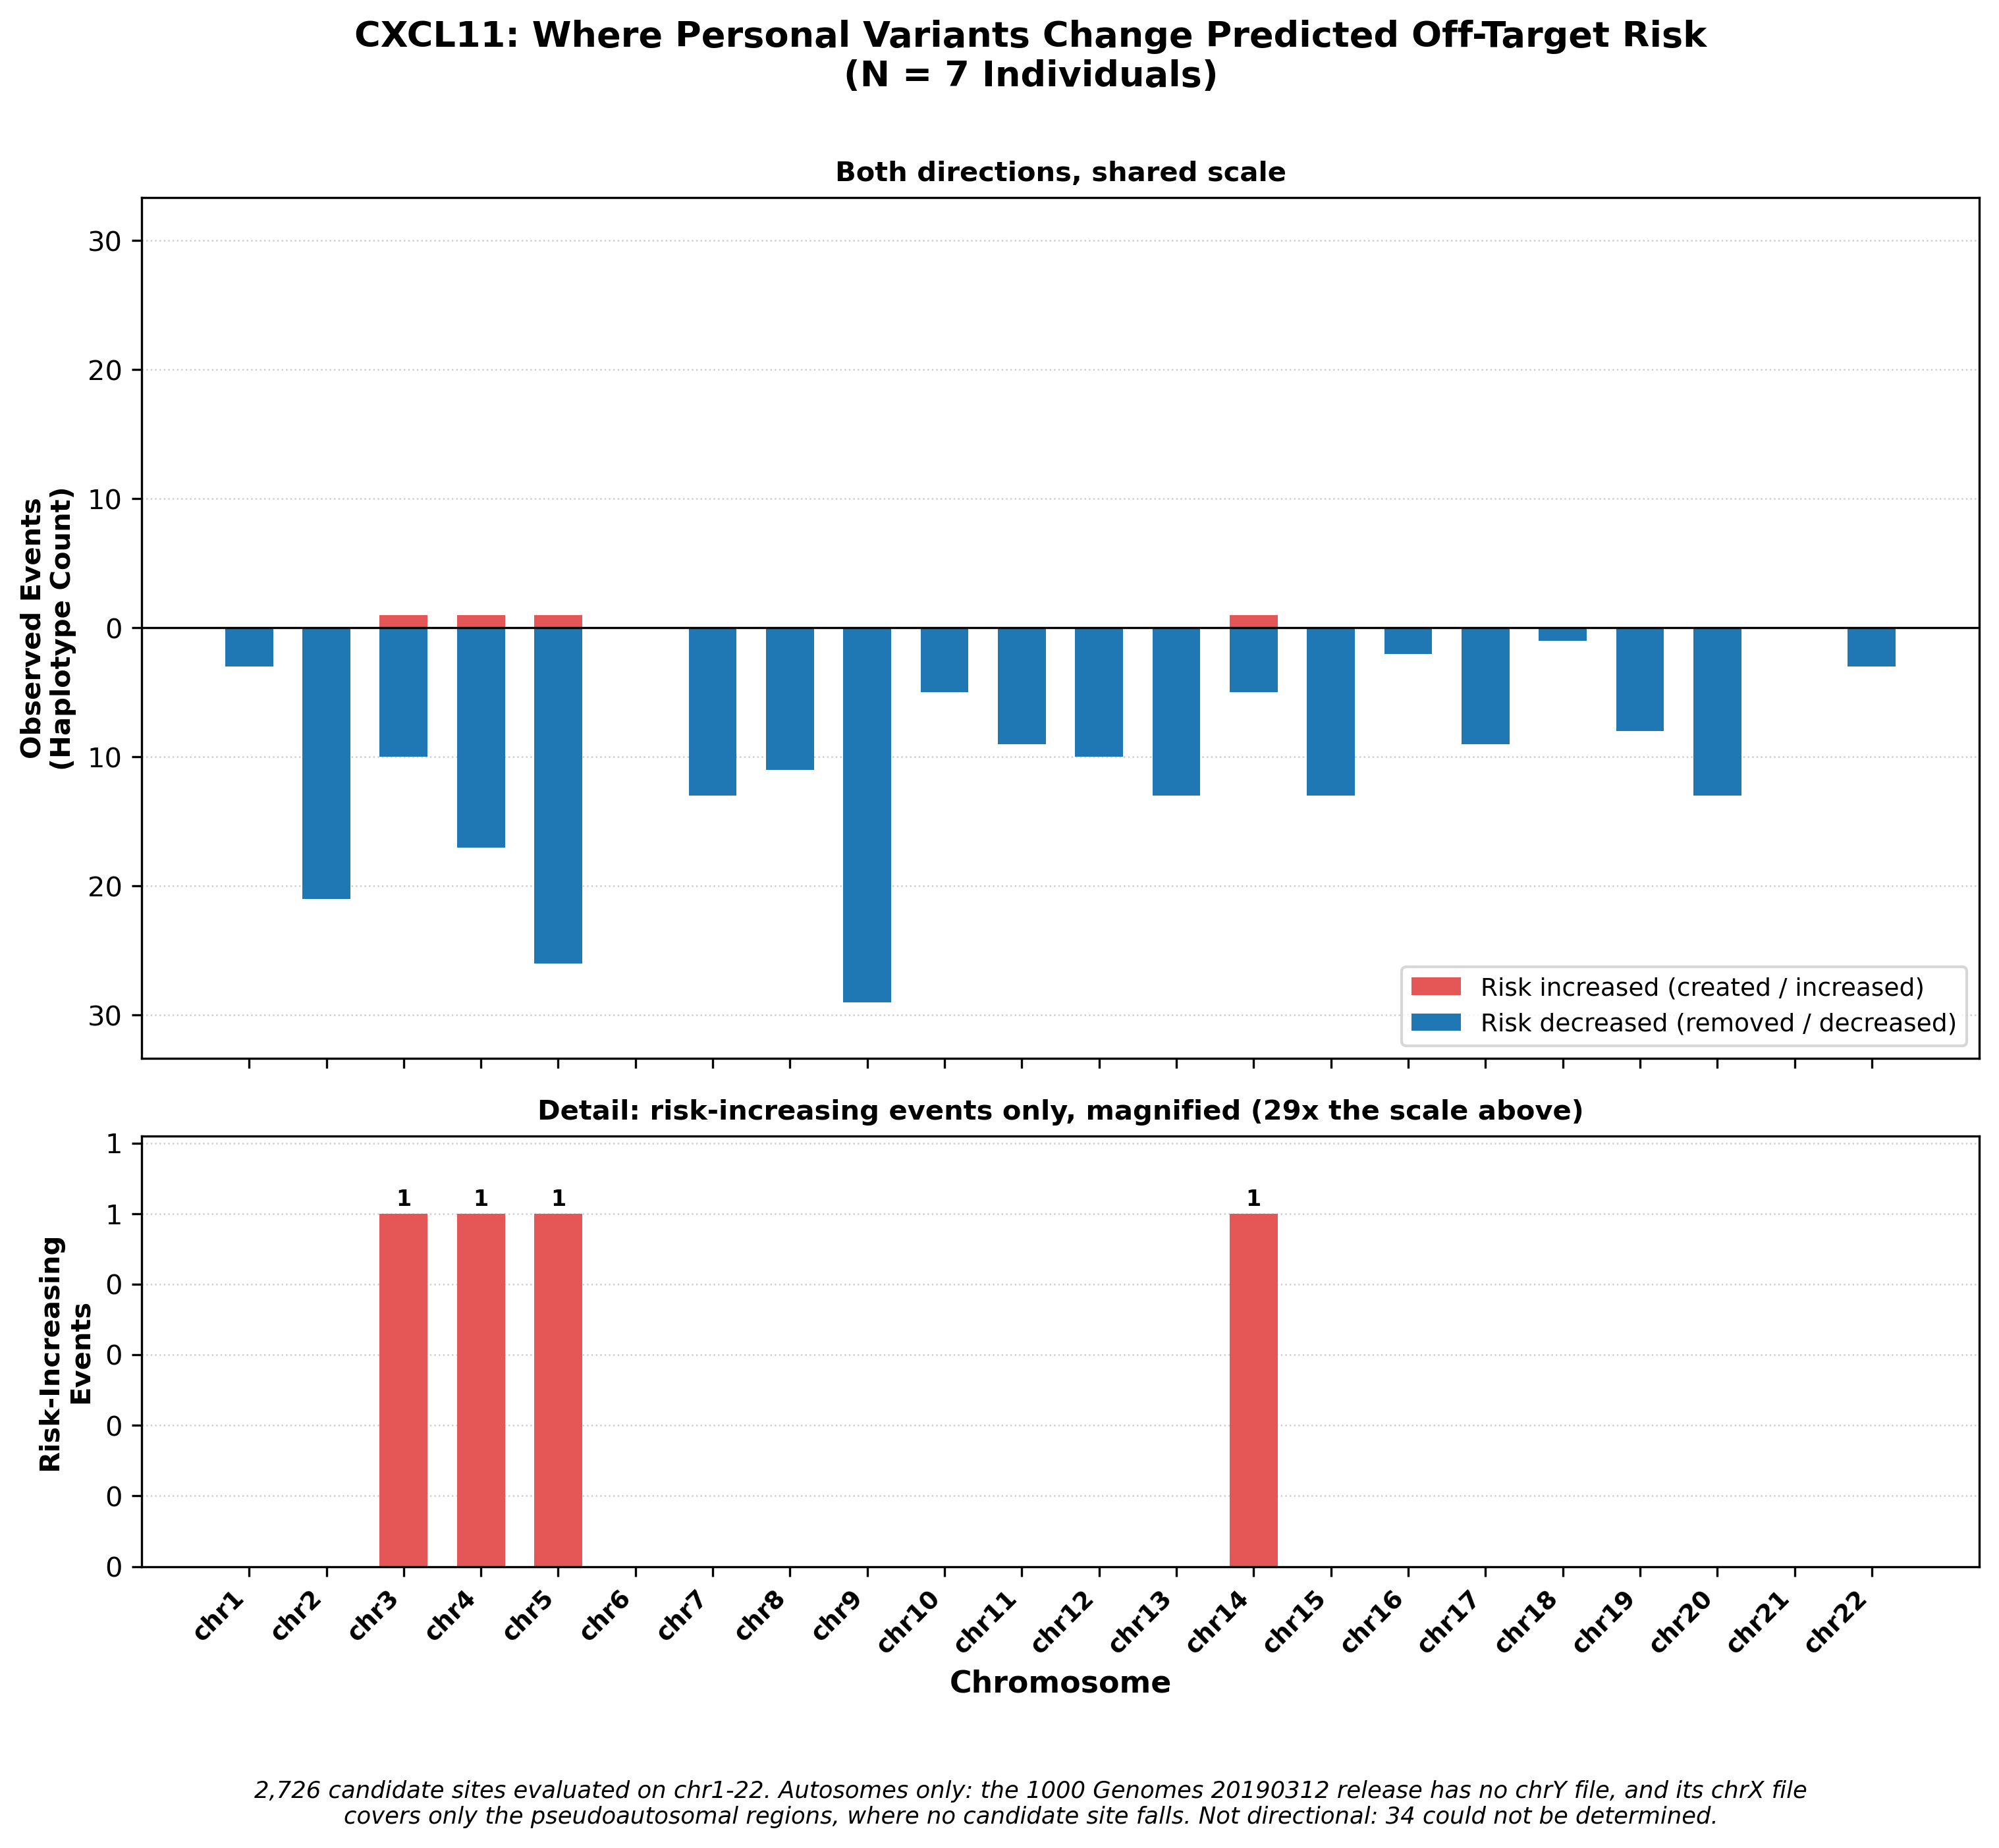

/Users/katrinamcmiddlin/repos/ifn646-task3/Task3/utils/variant_utils.py:458: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.95))


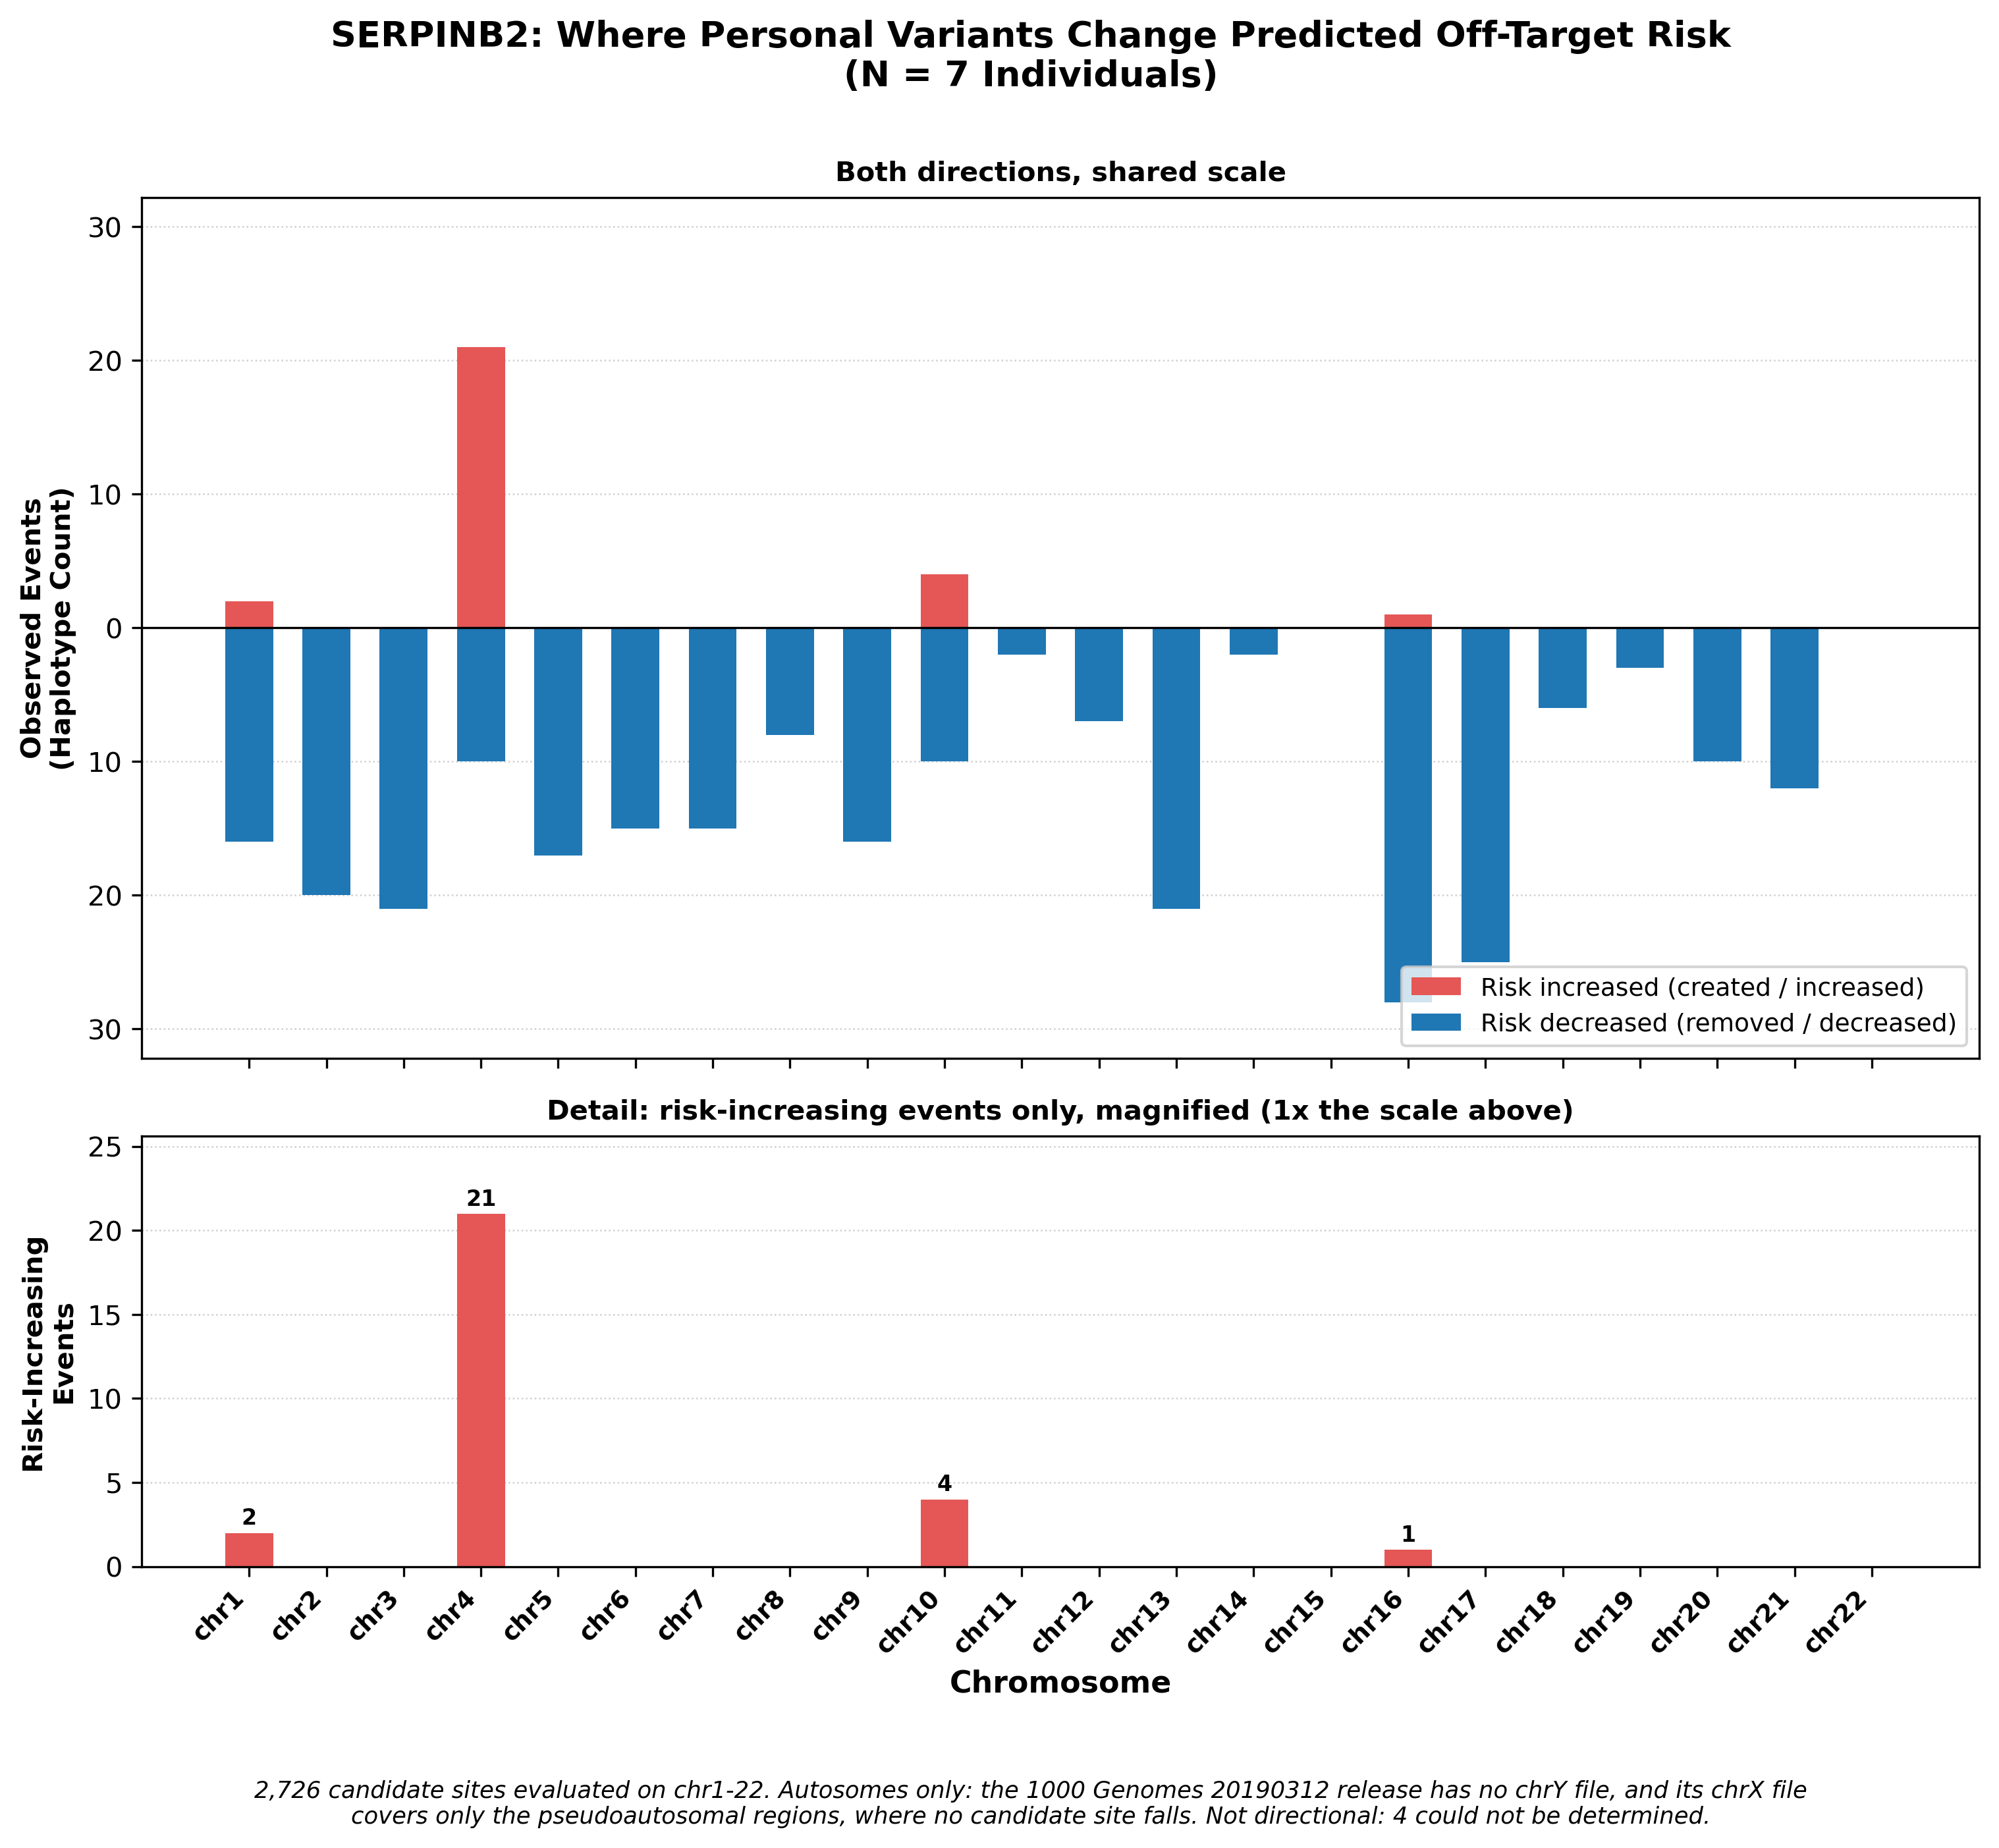

gene           CXCL11                                    ... SERPINB2        \
chrom               1   2   3   4   5  6   7   8   9 10  ...       13 14 15   
risk_increased      0   0   1   1   1  0   0   0   0  0  ...        0  0  0   
risk_decreased      3  21  10  17  26  0  13  11  29  5  ...       21  2  0   

gene                                     
chrom           16  17 18 19  20  21 22  
risk_increased   1   0  0  0   0   0  0  
risk_decreased  28  25  6  3  10  12  0  

[2 rows x 44 columns]

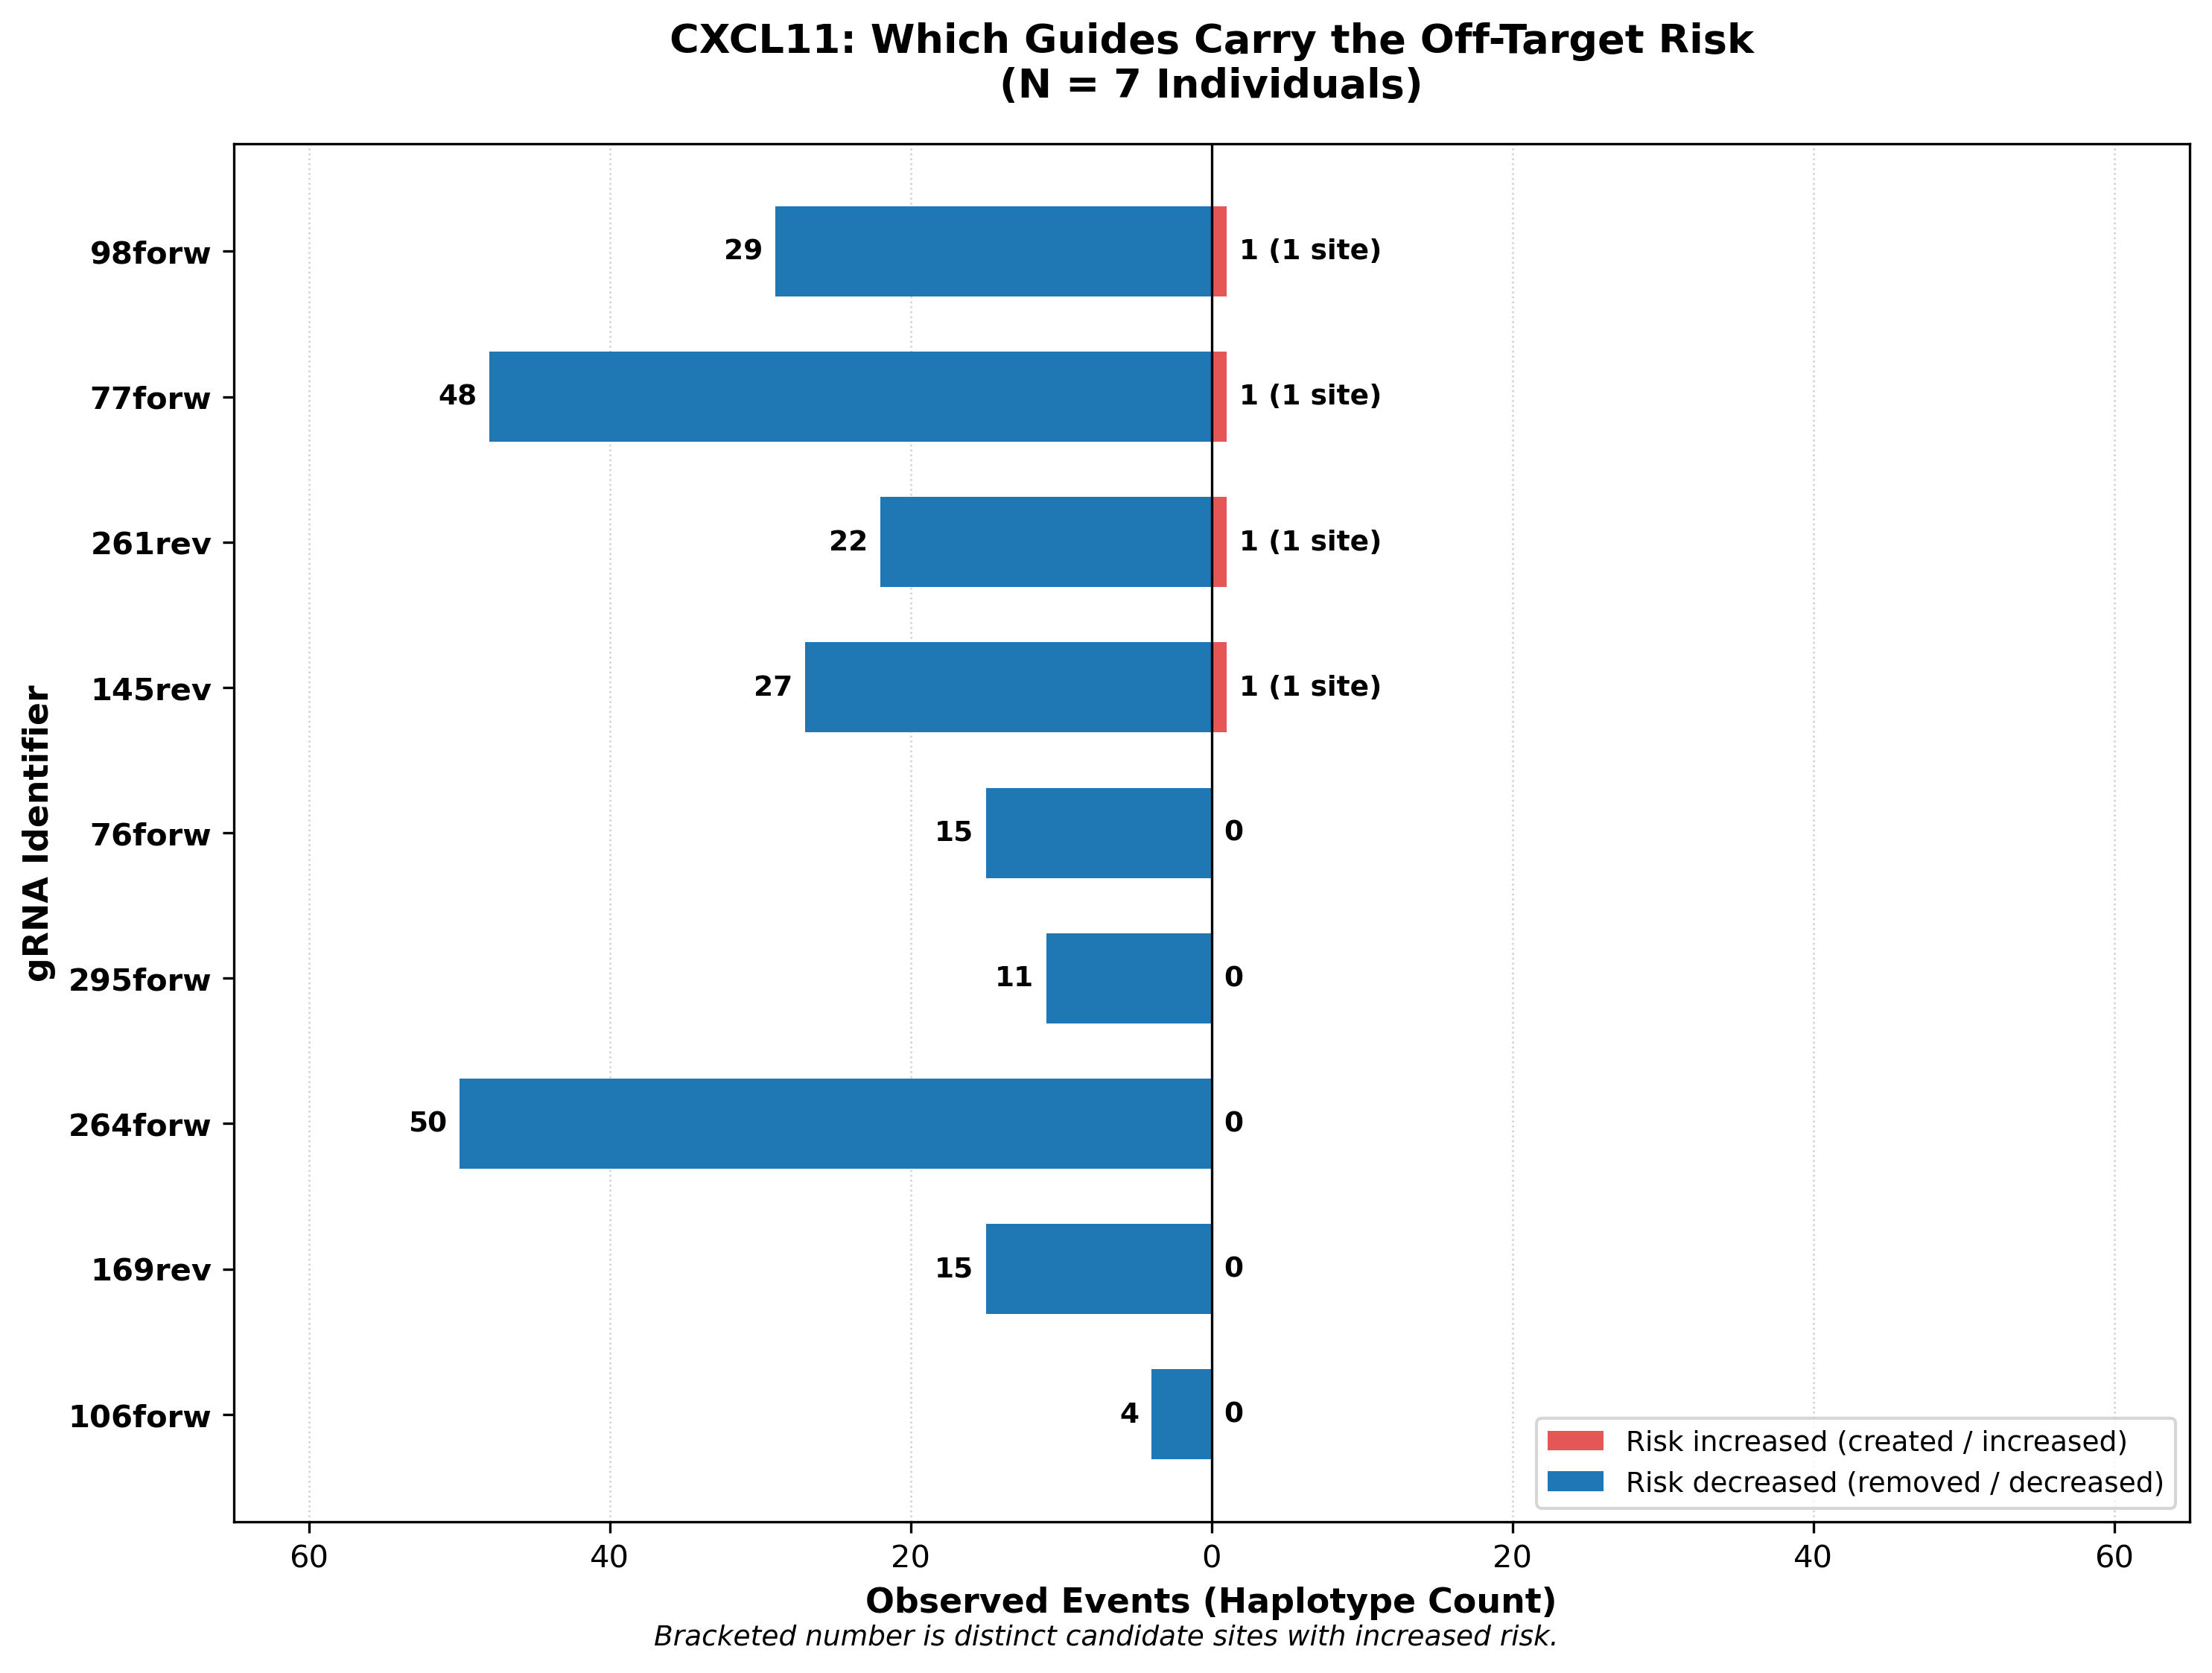

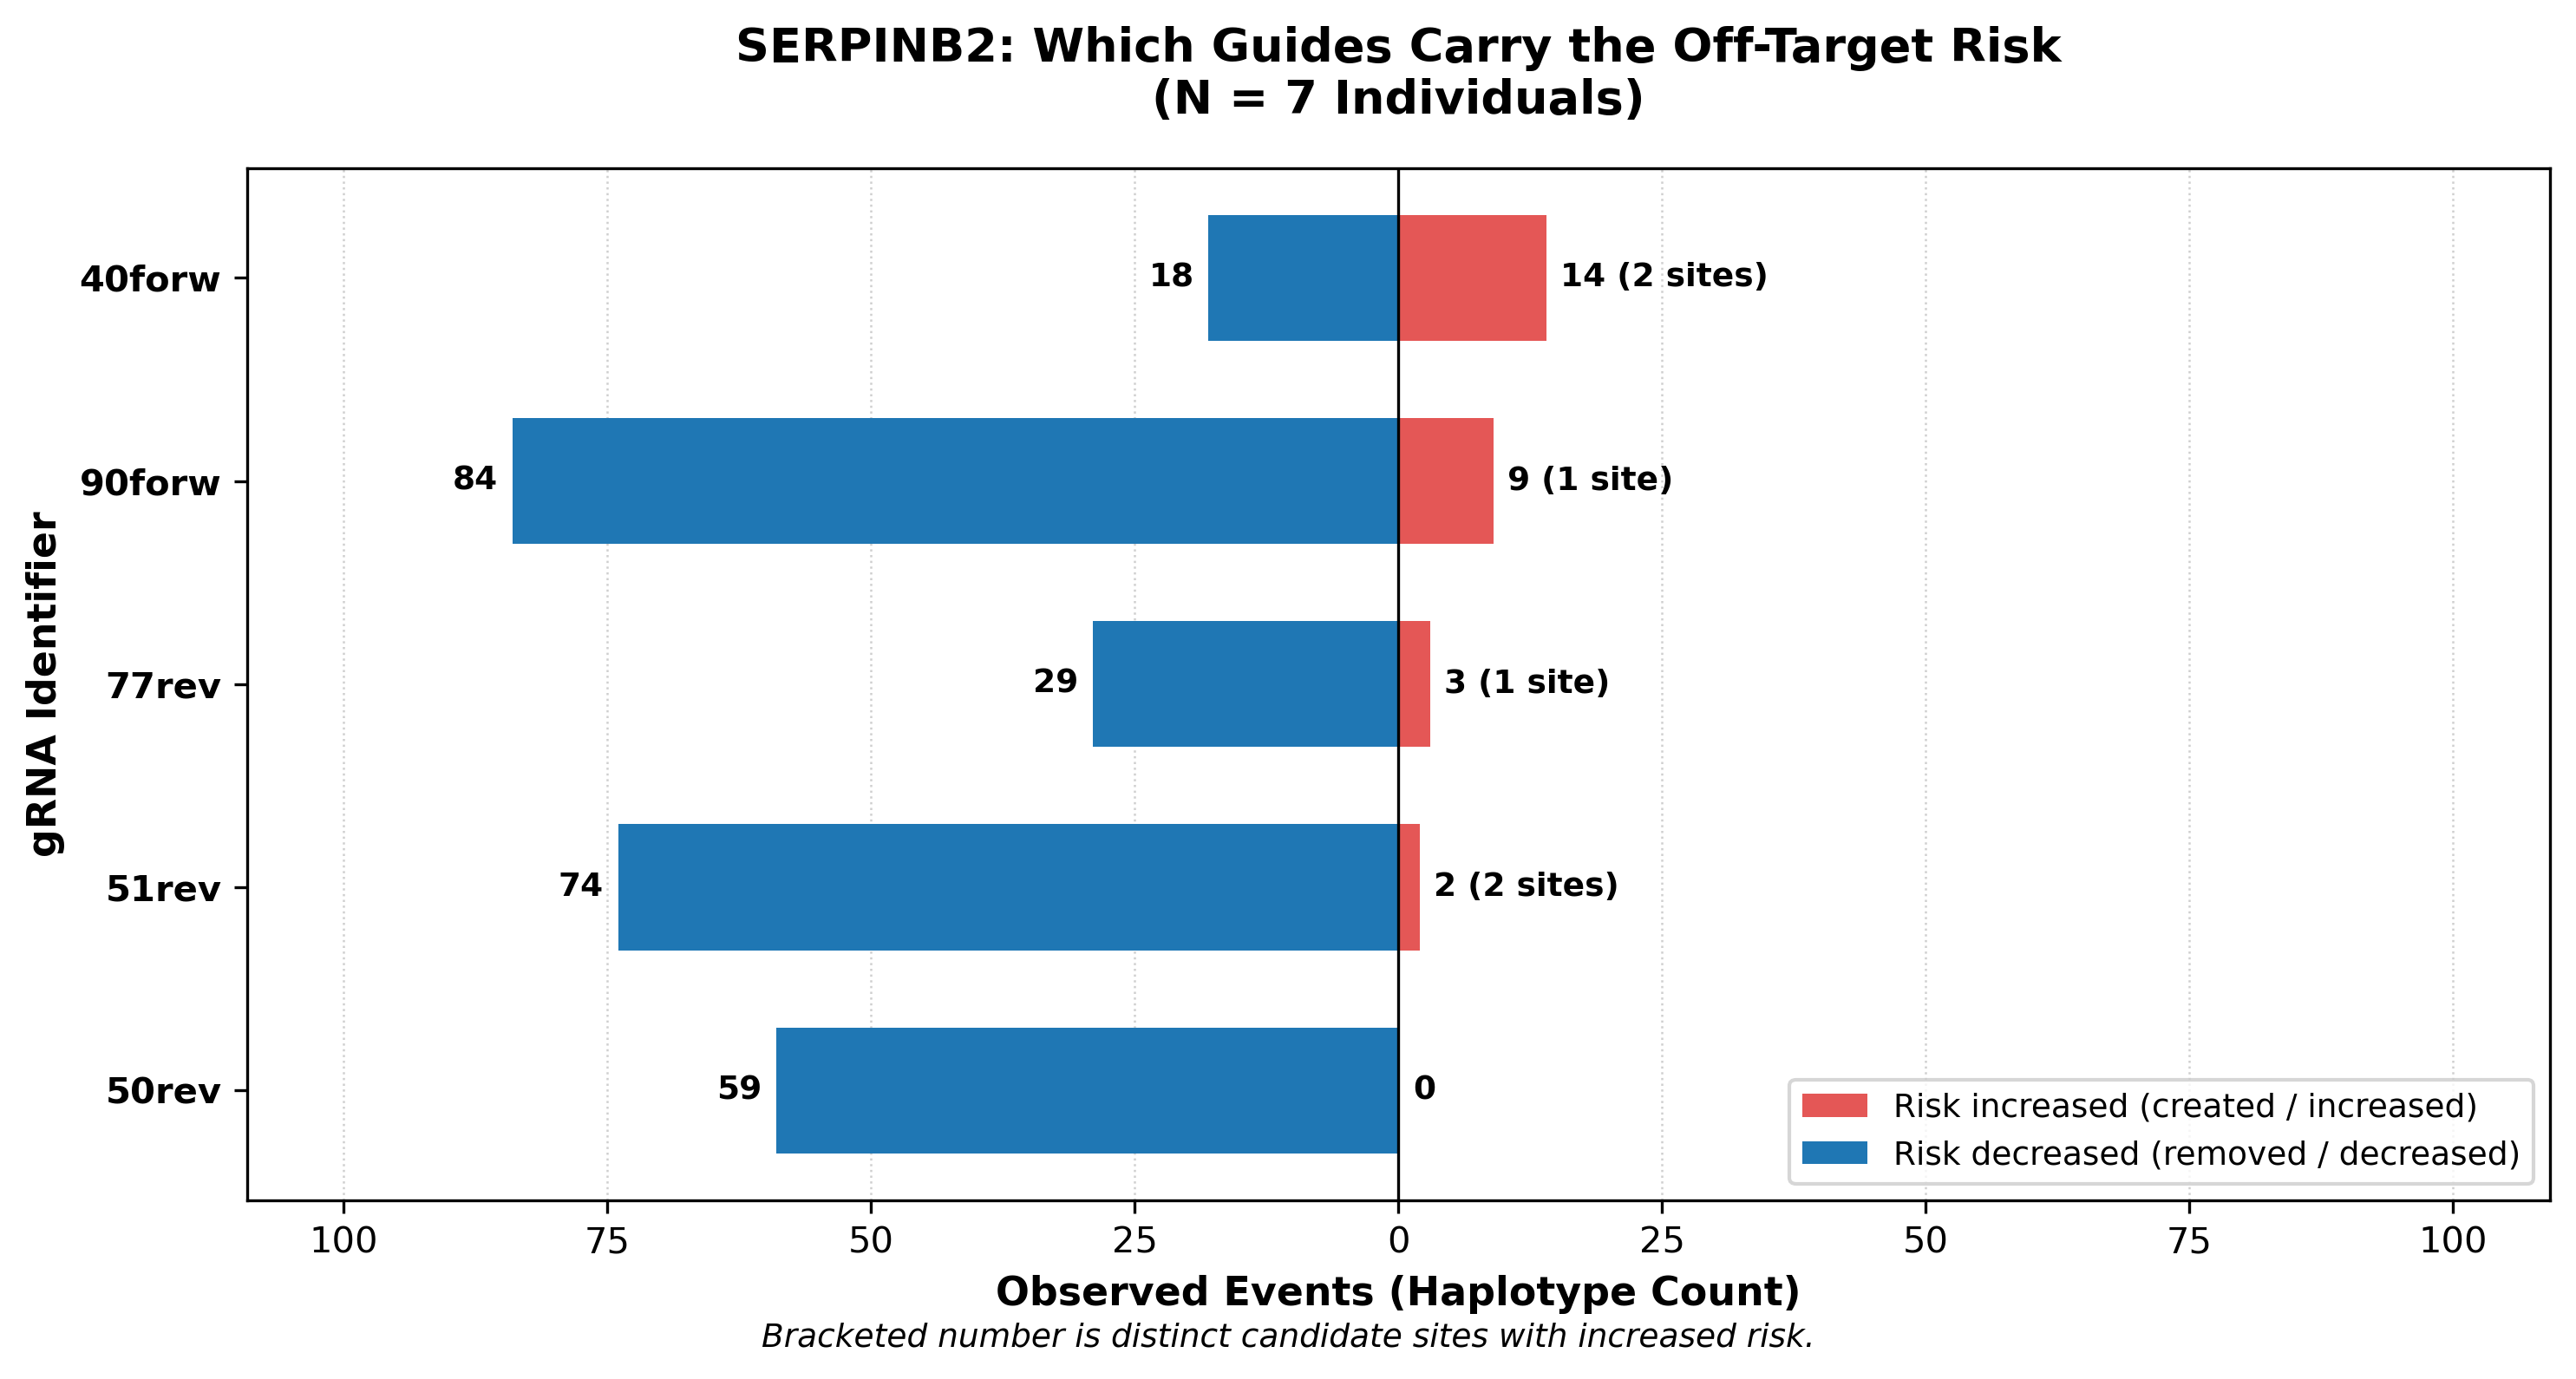

**Risk-increasing candidate sites: `10`**

,gene,guide_id,offtarget_id,chrom,start_1based,observations,carriers,carrier_pct,strand,locus_description,reference_mismatch_count_crispor,reference_mit_score,reference_cfd_score
0,SERPINB2,40forw,OT00328,4,90450821,12,7,100.000,-,intron:CCSER1,4.0,0.272333,0.725275
1,SERPINB2,90forw,OT00918,4,150035348,9,7,100.000,+,intergenic:RP11-423J7.1-DCLK2,4.0,0.211575,0.014006
2,SERPINB2,77rev,OT00070,10,69616327,3,3,42.857,+,intergenic:RP11-343J3.2-C10orf35,4.0,0.054593,0.086349
3,CXCL11,145rev,OT02099,4,70324276,1,1,14.286,-,intergenic:CSN3-CABS1,4.0,0.090605,0.033939
4,CXCL11,261rev,OT02382,14,62312475,1,1,14.286,-,intergenic:LINC00644-KCNH5,4.0,1.278707,0.270130
5,CXCL11,77forw,OT02289,5,109357617,1,1,14.286,+,intron:PJA2,4.0,0.024282,0.045085
6,CXCL11,98forw,OT02703,3,120777182,1,1,14.286,+,intron:GTF2E1,3.0,0.186459,0.000000
7,SERPINB2,40forw,OT00337,1,14817946,2,1,14.286,+,intergenic:AL034395.1-KAZN,4.0,0.227817,0.336111
8,SERPINB2,51rev,OT00482,10,72904315,1,1,14.286,+,intron:OIT3,4.0,0.316133,0.228438
9,SERPINB2,51rev,OT00702,16,85609408,1,1,14.286,+,intergenic:CTD-2542L18.1-GSE1,4.0,0.067219,0.021193


**Risk-increasing observations per guide, by chromosome**

chr1  chr3  chr4  chr5  chr10  chr14  chr16  total
gene     guide_id                                                    
SERPINB2 40forw       2     0    12     0      0      0      0     14
         90forw       0     0     9     0      0      0      0      9
         77rev        0     0     0     0      3      0      0      3
         51rev        0     0     0     0      1      0      1      2
CXCL11   145rev       0     0     1     0      0      0      0      1
         261rev       0     0     0     0      0      1      0      1
         77forw       0     0     0     1      0      0      0      1
         98forw       0     1     0     0      0      0      0      1

In [9]:
coverage = (
    validated_offtargets
    .assign(analysable=validated_offtargets['chrom'].isin(analyzer.vcfs.keys()))
    .groupby('gene')
    .agg(validated_sites=('offtarget_id', 'size'), analysable_sites=('analysable', 'sum'))
)
coverage['no_vcf_sites'] = coverage['validated_sites'] - coverage['analysable_sites']
coverage['percent_analysable'] = (100 * coverage['analysable_sites'] / coverage['validated_sites']).round(1)
display(Markdown('**Validated off-target candidates evaluated, by gene**'))
display(coverage)

if len(missing_vcf):
    display(Markdown('**Validated candidates on chromosomes with no VCF (not evaluated)**'))
    display(missing_vcf.groupby(['chrom', 'gene']).size().unstack(fill_value=0))

effects_by_chrom = personalised_offtargets.groupby(['chrom', 'offtarget_effect']).size().unstack(fill_value=0)
effects_by_chrom = effects_by_chrom.loc[sorted(effects_by_chrom.index, key=chrom_order)]
effects_by_chrom.to_csv(TABLE_DIR / 'task3_genome_wide_offtarget_effects_by_chromosome.tsv', sep='\t')
display(Markdown('**Off-target effects by chromosome (haplotype observations)**'))
display(effects_by_chrom)

fig_counts = plot_offtarget_events_by_chromosome(
    personalised_offtargets,
    output_path=FIGURE_DIR / 'task3_genome_wide_offtarget_events_by_chromosome.png',
)
display(fig_counts.T)

plot_offtarget_events_by_guide(
    personalised_offtargets,
    all_guides=guides,
    output_path=FIGURE_DIR / 'task3_genome_wide_offtarget_events_by_guide.png',
)

# Where each guide's risk-increasing sites actually are.
site_report = risk_increasing_site_report(
    personalised_offtargets, validated_offtargets, cohort_size=len(SAMPLES))
site_report.to_csv(TABLE_DIR / 'task3_genome_wide_risk_increasing_sites.tsv', sep='\t', index=False)
display(Markdown(f'**Risk-increasing candidate sites: `{len(site_report)}`**'))
display(site_report)

guide_by_chrom = risk_increasing_guide_by_chromosome(personalised_offtargets)
guide_by_chrom.to_csv(TABLE_DIR / 'task3_genome_wide_risk_increasing_by_guide_chromosome.tsv', sep='\t')
display(Markdown('**Risk-increasing observations per guide, by chromosome**'))
display(guide_by_chrom)

In [10]:
increased_cases = question2_summary.loc[
    (question2_summary['created_sites'] + question2_summary['increased_sites']).gt(0),
    ['sample_id', 'gene', 'guide_id', 'created_sites', 'increased_sites',
     'removed_sites', 'decreased_sites', 'unresolved_sites', 'answer'],
].sort_values(['sample_id', 'gene', 'guide_id'])

display(increased_cases)

,sample_id,gene,guide_id,created_sites,increased_sites,removed_sites,decreased_sites,unresolved_sites,answer
1,HG00142,CXCL11,145rev,0,1,0,3,0,MIXED_CHANGE
9,HG00142,SERPINB2,40forw,0,1,0,3,0,MIXED_CHANGE
13,HG00142,SERPINB2,90forw,0,1,1,13,0,MIXED_CHANGE
23,HG00178,SERPINB2,40forw,0,1,0,3,1,UNRESOLVED_OBSERVATIONS_PRESENT
25,HG00178,SERPINB2,51rev,0,1,3,8,0,MIXED_CHANGE
27,HG00178,SERPINB2,90forw,0,2,2,10,0,MIXED_CHANGE
35,HG00237,CXCL11,77forw,0,1,0,4,0,MIXED_CHANGE
37,HG00237,SERPINB2,40forw,0,2,0,3,0,MIXED_CHANGE
40,HG00237,SERPINB2,77rev,0,1,0,7,0,MIXED_CHANGE
41,HG00237,SERPINB2,90forw,0,1,2,9,0,MIXED_CHANGE


### Summary of findings

_To be written after reviewing the genome-wide results above. The chr4/chr18-only summary is in `03_variant_analysis_all_eligible-KM`._